In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

import xgboost as xgb

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [ ]:
df = pd.read_csv("/content/continuous dataset.csv")

df['datetime'] = pd.to_datetime(df['datetime'])

df = df.sort_values('datetime').reset_index(drop=True)

In [ ]:
df['hour'] = df['datetime'].dt.hour
df['dayofweek'] = df['datetime'].dt.dayofweek
df['month'] = df['datetime'].dt.month
df['weekend'] = df['dayofweek'].isin([5,6]).astype(int)

In [ ]:
df['lag24'] = df['nat_demand'].shift(24)
df['lag48'] = df['nat_demand'].shift(48)
df['lag168'] = df['nat_demand'].shift(168)

df = df.dropna().reset_index(drop=True)

In [ ]:
target_column = "nat_demand"

features = [
"T2M_toc","QV2M_toc","TQL_toc","W2M_toc",
"T2M_san","QV2M_san","TQL_san","W2M_san",
"T2M_dav","QV2M_dav","TQL_dav","W2M_dav",
"Holiday_ID","holiday","school",
"hour","dayofweek","month","weekend",
"lag24","lag48","lag168"
]

data = df[features + [target_column]]

In [ ]:
scaler = MinMaxScaler()

data_scaled = scaler.fit_transform(data)

data_scaled = pd.DataFrame(data_scaled, columns=data.columns)

In [ ]:
SEQ_LENGTH = 168

X = []
y = []

target_index = data_scaled.columns.get_loc(target_column)

for i in range(len(data_scaled) - SEQ_LENGTH):

    X.append(data_scaled.iloc[i:i+SEQ_LENGTH].values)
    y.append(data_scaled.iloc[i+SEQ_LENGTH, target_index])

X = np.array(X)
y = np.array(y)

print(X.shape, y.shape)

(47712, 168, 23) (47712,)


In [ ]:
split = int(0.8 * len(X))

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

In [ ]:
X_train_t = torch.tensor(X_train, dtype=torch.float32)
X_test_t = torch.tensor(X_test, dtype=torch.float32)

y_train_t = torch.tensor(y_train, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32)

train_loader = DataLoader(
    TensorDataset(X_train_t, y_train_t),
    batch_size=64,
    shuffle=True
)

test_loader = DataLoader(
    TensorDataset(X_test_t, y_test_t),
    batch_size=64
)

In [ ]:
class PositionalEncoding(nn.Module):

    def __init__(self, d_model, max_len=5000):

        super().__init__()

        pe = torch.zeros(max_len, d_model)

        position = torch.arange(0, max_len).unsqueeze(1)

        div_term = torch.exp(
            torch.arange(0, d_model, 2) * (-np.log(10000.0) / d_model)
        )

        pe[:,0::2] = torch.sin(position * div_term)
        pe[:,1::2] = torch.cos(position * div_term)

        pe = pe.unsqueeze(0)

        self.register_buffer("pe", pe)

    def forward(self, x):

        return x + self.pe[:,:x.size(1)]

In [ ]:
class TransformerModel(nn.Module):

    def __init__(self, input_dim):

        super().__init__()

        d_model = 128

        self.input_proj = nn.Linear(input_dim, d_model)

        self.pos = PositionalEncoding(d_model)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=4,
            dim_feedforward=256,
            dropout=0.1,
            batch_first=True
        )

        self.encoder = nn.TransformerEncoder(
            encoder_layer,
            num_layers=3
        )

        self.fc = nn.Linear(d_model,1)

    def forward(self,x):

        x = self.input_proj(x)

        x = self.pos(x)

        x = self.encoder(x)

        x = x[:,-1,:]

        return self.fc(x)

In [ ]:
input_dim = X_train.shape[2]

model = TransformerModel(input_dim).to(device)

criterion = nn.MSELoss()

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [ ]:
epochs = 50

for epoch in range(epochs):

    model.train()

    total_loss = 0

    for xb,yb in train_loader:

        xb = xb.to(device)
        yb = yb.to(device)

        optimizer.zero_grad()

        pred = model(xb).squeeze()

        loss = criterion(pred,yb)

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    print("Epoch",epoch+1,"Loss",total_loss/len(train_loader))

Epoch 1 Loss 0.02877322883735968
Epoch 2 Loss 0.0019396362902083352
Epoch 3 Loss 0.0011924524204392092
Epoch 4 Loss 0.0009643444810936249
Epoch 5 Loss 0.0007865798780133002
Epoch 6 Loss 0.0006315452702381684
Epoch 7 Loss 0.0005758994605456178
Epoch 8 Loss 0.0004721725091140817
Epoch 9 Loss 0.0004372358459570185
Epoch 10 Loss 0.00040948072195749643
Epoch 11 Loss 0.0004000728667397411
Epoch 12 Loss 0.00034951063924936273
Epoch 13 Loss 0.00036325832830634363
Epoch 14 Loss 0.00030923124395058936
Epoch 15 Loss 0.0003117175983118597
Epoch 16 Loss 0.0002885141215152404
Epoch 17 Loss 0.00029089304609421153
Epoch 18 Loss 0.00027815243622439817
Epoch 19 Loss 0.0002548980168897621
Epoch 20 Loss 0.00026817748993299774
Epoch 21 Loss 0.00026455214507676975
Epoch 22 Loss 0.00024544171209400675
Epoch 23 Loss 0.0002354614446644587
Epoch 24 Loss 0.00024287550997231203
Epoch 25 Loss 0.0002304261779652283
Epoch 26 Loss 0.00024217488914734015
Epoch 27 Loss 0.00022580807005703431
Epoch 28 Loss 0.00022833191

In [ ]:
model.eval()

transformer_preds = []

with torch.no_grad():

    for xb,yb in test_loader:

        xb = xb.to(device)

        out = model(xb).squeeze()

        transformer_preds.extend(out.cpu().numpy())

transformer_preds = np.array(transformer_preds)

In [ ]:
residuals = y_test - transformer_preds

X_test_flat = X_test.reshape(X_test.shape[0], -1)

xgb_model = xgb.XGBRegressor(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05
)

xgb_model.fit(X_test_flat, residuals)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=200,
             n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
xgb_residual_pred = xgb_model.predict(X_test_flat)

final_pred = transformer_preds + xgb_residual_pred

In [ ]:
target_min = df[target_column].min()
target_max = df[target_column].max()

pred_real = final_pred*(target_max-target_min)+target_min
actual_real = y_test*(target_max-target_min)+target_min

In [ ]:
mae = mean_absolute_error(actual_real, pred_real)

rmse = np.sqrt(mean_squared_error(actual_real, pred_real))

mape = np.mean(np.abs((actual_real - pred_real)/actual_real))*100

print("Hybrid Model Performance")

print("MAE:",mae)
print("RMSE:",rmse)
print("MAPE:",mape)

Hybrid Model Performance
MAE: 8.62792407403087
RMSE: 11.30285490126891
MAPE: 0.7163737833677681


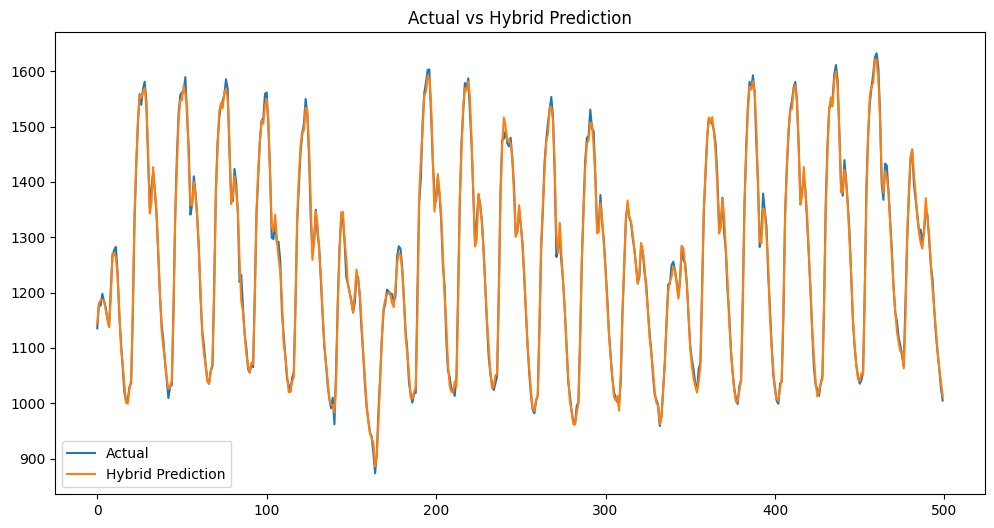

In [ ]:
plt.figure(figsize=(12,6))

plt.plot(actual_real[:500],label="Actual")

plt.plot(pred_real[:500],label="Hybrid Prediction")

plt.legend()

plt.title("Actual vs Hybrid Prediction")

plt.show()

In [ ]:
epochs = 50

train_losses = []

for epoch in range(epochs):

    model.train()

    total_loss = 0

    for xb, yb in train_loader:

        xb = xb.to(device)
        yb = yb.to(device)

        optimizer.zero_grad()

        pred = model(xb).squeeze()

        loss = criterion(pred, yb)

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)

    train_losses.append(avg_loss)

    print("Epoch", epoch+1, "Loss", avg_loss)

Epoch 1 Loss 0.0001847743927830693
Epoch 2 Loss 0.00019050015130895774
Epoch 3 Loss 0.0001729931140368628
Epoch 4 Loss 0.00017983292682142968
Epoch 5 Loss 0.00018142789158629062
Epoch 6 Loss 0.00018752915988370293
Epoch 7 Loss 0.0001839699347438548
Epoch 8 Loss 0.0001816352743061569
Epoch 9 Loss 0.0001646110772777667
Epoch 10 Loss 0.00017792246095874967
Epoch 11 Loss 0.0001814644242304091
Epoch 12 Loss 0.00018213431694355896
Epoch 13 Loss 0.00017501326929324483
Epoch 14 Loss 0.0001776331563735064
Epoch 15 Loss 0.0001678559475024956
Epoch 16 Loss 0.00016698575626843853
Epoch 17 Loss 0.00017072813019850268
Epoch 18 Loss 0.0001686884452968815
Epoch 19 Loss 0.0002292471510442785
Epoch 20 Loss 0.00016616525933129122
Epoch 21 Loss 0.0001703213595066526
Epoch 22 Loss 0.00016174839225973446
Epoch 23 Loss 0.00015849346083594162
Epoch 24 Loss 0.00016304404980138762
Epoch 25 Loss 0.00015675544622281083
Epoch 26 Loss 0.00016808028364235416
Epoch 27 Loss 0.00018343464913563506
Epoch 28 Loss 0.00016

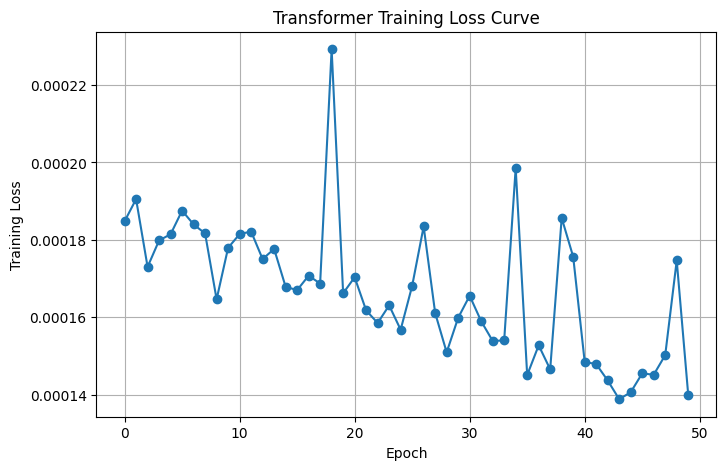

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(train_losses, marker='o')

plt.xlabel("Epoch")

plt.ylabel("Training Loss")

plt.title("Transformer Training Loss Curve")

plt.grid(True)

plt.show()